In [2]:
from qeep import plot

import matplotlib.pyplot as plt

import numpy as np

import matplotlib.pyplot as plt

import yaml
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)


import os
os.environ['PATH'] = os.path.expanduser("~/texlive/2025/bin/aarch64-linux") + ":" + os.environ['PATH']

style_path = "paper.mplstyle"
plt.style.use(style_path)

In [2]:
configuration = '../../configs/abacus/config_desi_asymm.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

In [3]:
name = config["name"]

path = f"../../results/{name}/"
path = f"/users/odarwish/results/desi_base_asymm/"

norm = np.load(path+f"analysis_theory_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysis_theory_variance_AB.npy", allow_pickle = True).item()
bis = np.load(path+f"analysis_theory_shot_bispectrum_AB.npy", allow_pickle = True).item()
tris = np.load(path+f"analysis_theory_shot_trispectrum_AB.npy", allow_pickle = True).item()

In [5]:
from qeep import qeutils

In [22]:
P_A_signal_jax = qeutils.get_interpolated_standard(gen_nl_power[:,0], gen_nl_power[:,1])

In [9]:
Ks_ = np.linspace(1e-3, 0.5, 1000)

In [23]:
%timeit P_A_signal_jax(Ks_)

209 μs ± 2.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [11]:
from interpax import interp1d

In [21]:
%timeit interp1d(Ks, gen_nl_power[:,0], gen_nl_power[:,1], method="nearest")

150 μs ± 838 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [24]:
b10_A, b2_fid, bs2_fid = 1.6, -0.3, qeutils.bs2_coev(1.6)

In [25]:
Fkernels = [qeutils.Fg, qeutils.Fs, qeutils.Ft]
Fbiases = [qeutils.bias_g(b10_A, b2_fid), qeutils.bias_s(b10_A), qeutils.bias_t(b10_A, bs2_fid)]

In [26]:
bispectrum_cont = qeutils.get_bispectrum_XYZ(P_A_signal_jax, P_A_signal_jax, P_A_signal_jax, Fkernels, Fbiases)

In [50]:
x = jnp.array([0.1*jnp.ones(Ks.size), 0.5*jnp.ones(Ks.size), 0.5*jnp.ones(Ks.size)])
K = Ks
k1, k2, mask = qeutils.get_k1_k2_mask(K, x[0], x[-1], x[1], kmin, kmax)
k3 = k1+k2
k3_mag = jnp.linalg.norm(k3, axis=-1)
k1_mag = jnp.linalg.norm(k1, axis=-1)
k2_mag = jnp.linalg.norm(k2, axis=-1)

In [52]:
%timeit bispectrum_cont(k1, k2, k3, k1_mag, k2_mag, k3_mag)

389 μs ± 19.7 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Let's define the power spectra

In [4]:
from qeep import biases
from qeep import qeresults as qres
import jax
from jax import numpy as jnp

def plinear():
    return plinf(Ks)

def E_bottaro():
    z_eq = 3400
    a_eq = 1/(1+z_eq)
    a = 1.
    fchi = 1.
    factor = jnp.log(a/a_eq)-181/90
    factor *= fchi
    factor *= 6/5
    return factor

def G(epsilon, one = 1):
    E = E_bottaro()
    return 1+epsilon*E*one

def get_CG(v, asymm_shift = 1., only_asymm_shift = 0.):  
    """
    Effective biases.

    asymm_shift = 1., means we include the C^{S}_{[AB]} signature from the anti-symmetric term. If zero, this is not included.
    only_asymm_shift = 0., means that we are including G and T anti-symmetric. If 1., we exclude them. This is useful to check origin of constraints on epsilon.
    """
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    Cg = biases.get_Cg_biases(e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    return Cg


def get_tot_bias_Cg(normalization, Cg, responses):
    """
    This is the overall bias coming from all the present terms, given Cg.
    """
    partials = normalization * responses * Cg[:, jnp.newaxis]
    bias = jnp.sum(partials, axis=0)
    return jnp.nan_to_num(bias)

def get_tot_bias(v, normalization, responses, asymm_shift = 1, only_asymm_shift = 0.):
    """
    This is the overall bias given your parameter vector v, the normalization of the estimator, and the responses.
    """
    Cg = get_CG(v, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    return get_tot_bias_Cg(normalization, Cg, responses)

def galaxy_power_spectrum(v, nshot, growth_eps = 1.):
    """
    Standard power spectrum with linear bias and shot noise.
    We also include an additional growth factor depending on epsilon.
    """
    eps, b1X = v
    return  b1X**2*plinear()*G(eps, growth_eps)**2 + nshot
    
def reconstruction_cross_spectrum(v, normalization, responses, bisp_noise, asymm_shift = 1, only_asymm_shift = 0., growth_eps = 1.):
    """
    bisp_noise, bispectrum shot noise
    growth_eps, include growth term epsilon or not
    """
    bias = get_tot_bias(v, normalization, responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    b1X = v[1]
    signal = b1X*bias*plinear()*G(v[0], growth_eps)**3
    return signal + bisp_noise

def reconstruction_auto_spectrum(v, normalization, responses, var_noise, tris_noise, signal = 1., asymm_shift = 1, only_asymm_shift = 0, growth_eps = 1.):
    bias = get_tot_bias(v, normalization, responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    signal = bias**2*plinear()*signal*G(v[0], growth_eps)**4
    return signal + var_noise + tris_noise

In [5]:
def get_functions(key, QR, shot_noise = 1., variance_factor = 1., bispectrum_factor = 1., trispectrum_factor = 1., asymm_shift = 1., only_asymm_shift = 0., growth_eps = 0., vfid = None, fiducial_auto = False, fiducial_cross = False, fiducial_power = False, keys = ["g", "s", "t", "ga", "sa", "ta"]):
    
    #e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v

    variance_noise = QR.get_get_variance()(key)*variance_factor
    bispectrum_noise = QR.get_get_bispectrum()(key)*bispectrum_factor if bispectrum_factor != 0 else 0
    trispectrum_noise = QR.get_get_trispectrum()(key)*trispectrum_factor if trispectrum_factor != 0 else 0
    normalization = QR.get_get_norm()(key)
    out_normalization_AB = QR.get_out_normalization_AB()
    
    responses = qres.get_normalization_array(key, keys, Ks, out_normalization_AB)
    
    CAR = lambda v: reconstruction_cross_spectrum(v if not fiducial_cross else vfid, normalization, responses, bispectrum_noise, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets cross-spectrum
    
    CRR = lambda v: reconstruction_auto_spectrum(v if not fiducial_auto else vfid, normalization, responses, variance_noise, trispectrum_noise, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets reconstruction auto-spectrum
    
    CAA = lambda v: galaxy_power_spectrum(v[:2] if not fiducial_power else vfid[:2], shot_noise, growth_eps = growth_eps) #gets galaxy auto-spectrum

    return CAA, CAR, CRR


def get_v(vA):
    e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = vA
    b1B, b2B, bs2B = b1A, b2A, bs2A
    v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    return v

def get_functions_vA_only(CAA, CAR, CRR):
        
    def CAA_(vA):
        return CAA(get_v(vA))

    def CAR_(vA):
            return CAR(get_v(vA))

    def CRR_(vA):
            return CRR(get_v(vA))

    return CAA_, CAR_, CRR_


def get_cov(CAAf, CARf, CRRf):
    @jax.jit
    def covariance_full(K_array, v):

        n_probes = 2

        C = jnp.zeros((len(K_array), n_probes, n_probes))
        
        CAR = CARf(v)
        
        C = C.at[:, 0, 0].set(CRRf(v))
        C = C.at[:, 0, 1].set(CAR)
        C = C.at[:, 1, 0].set(CAR)
        C = C.at[:, 1, 1].set(CAAf(v))
        
        return C
    
    return covariance_full

def get_Ofuncs(CAAf, CARf, CRRf):
    Ofunc = lambda K_arr, v: CARf(v)
    variance_func = lambda K_arr, v: CAAf(v)*CRRf(v)+CARf(v)**2
    return Ofunc, variance_func

## Comparing analytical with numerical results

In [6]:
def Fanalytical(efid, CAA, CAR, CRR, corr_coeff_factor = 1.):
    #this function can be generalized by just passing CAA, CAR, CRR in function of one var
    
    CAA_ = lambda e: CAA(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    CAR_ = lambda e: CAR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    CRR_ = lambda e: CRR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    
    der_gg = jax.jacfwd(CAA_)(efid)
    gg = CAA_(efid)
    fgg = der_gg/gg
    
    der_gr = jax.jacfwd(CAR_)(efid)
    gr = CAR_(efid)
    fgr = der_gr/gr
    
    der_rr = jax.jacfwd(CRR_)(efid)
    rr = CRR_(efid)
    frr = der_rr/rr

    rc2 = gr**2/(gg*rr)*corr_coeff_factor

    A = fgg-2*rc2*fgr
    A = A**2
    B = 2*rc2*(1-rc2)*fgr**2
    C = 2*rc2*frr*(fgg-2*fgr)
    D = frr**2
    return (A+B+C+D)*1/2*1/(1-rc2)**2

In [7]:
mainkey = "n"

biases_dict = config["bias"]
number_density = config["number_density"]

nbar_A = number_density["nbar_A"]
nbar_B = number_density["nbar_B"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 1e-3

b2A, b2B = -0.3, -0.3
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1

vA = jnp.array([e*0., b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])  #fiducial point

QR = qres.QEResults(config)
responses_dict = QR.get_out_normalization_AB()
responses = qres.get_normalization_array(mainkey, ["g", "s", "t", "ga", "sa", "ta"], Ks, responses_dict)

keys = ["g", "s", "t", "ga", "sa", "ta"]

In [8]:
from qeep import fisher

shot_noise = 0.
variance_factor = 0.
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

asymm_shift, only_asymm_shift = 1., 0.
bias_temp_function = lambda e: get_tot_bias(get_v(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])), QR.get_get_norm()(mainkey), responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)

In [9]:
CAA, CAR, CRR_with_var = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=1e-10,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
O, Ovar = get_Ofuncs(CAA, CAR, CRR_with_var)

In [10]:
index = 0
e = 0.
derivative = jax.jacfwd(bias_temp_function)(e)
FF = 0.5*(derivative/bias_temp_function(e))**2
err_cross_analytical = FF**-0.5 #analytical cross-error
############
O, Ovar = get_Ofuncs(CAA, CAR, CRR_with_var)
F_cross = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
F_cross = jnp.nan_to_num(F_cross)[:, index, index]
err_cross_numerical = F_cross**-0.5 #numerical cross-error
############
FF_joint = Fanalytical(0., CAA, CAR, CRR_with_var)
err_joint_analytical = FF_joint**-0.5 #analytical joint-error
############
cov = get_cov(CAA, CAR, CRR_with_var)
F_joint = fisher.fisher_per_mode(vA, Ks, cov)[:, index, index]
err_joint_numerical = (F_joint**-0.5)
############ ALTERNATIVE NUMERICAL
cov_function = get_cov(CAA, CAR, CRR_with_var)
covf = lambda e: cov_function(Ks, jnp.array([e[0], b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
covariance = covf(jnp.array([0.]))
der_covariance = jax.jacfwd(covf)(jnp.array([0.]))
inv_covariance = jnp.linalg.inv(covariance)
inv_covariance = jnp.nan_to_num(inv_covariance, posinf = 0.)
FF_joint_code = jnp.einsum('kij,kjla,klm, kmib ->kab', inv_covariance, der_covariance, inv_covariance, der_covariance)*0.5
err_joint_numerical_alt = FF_joint_code[:, index, index]**-0.5 #0 index is e

############
FF_joint = Fanalytical(0., CAA, CAR, CRR_with_var, corr_coeff_factor = 0.)
err_joint_analytical_indep = FF_joint**-0.5 #analytical joint-error, but independent, cross-corr coeff r = 0

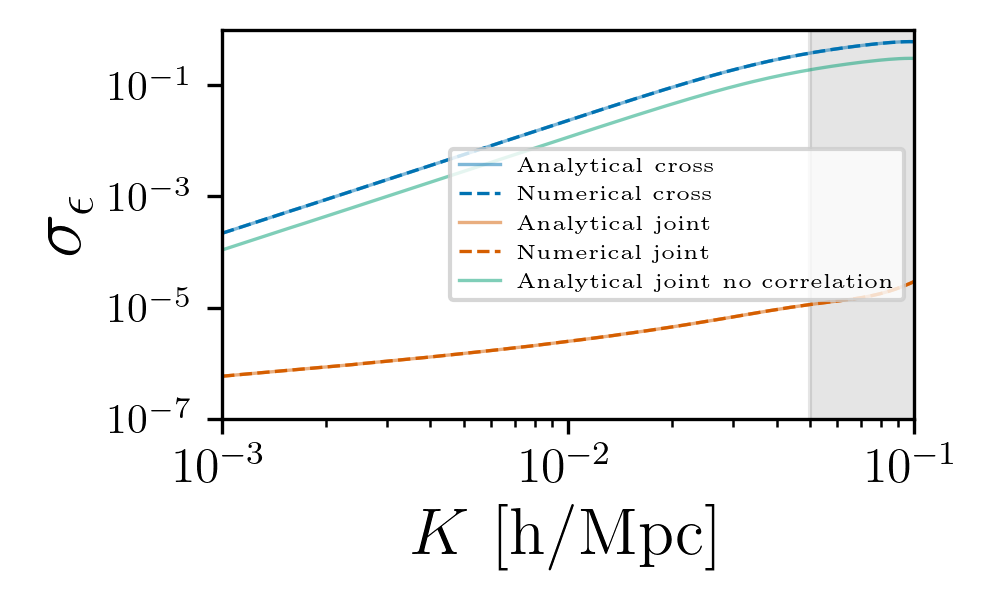

In [11]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig)#, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

ax.loglog(Ks, err_cross_analytical, label = "Analytical cross", alpha = 0.5, color = plot.COLORBLIND_PALETTE[0])
ax.loglog(Ks, err_cross_numerical, label = "Numerical cross", ls = "--", color = plot.COLORBLIND_PALETTE[0])

ax.loglog(Ks, err_joint_analytical, label = "Analytical joint", alpha = 0.5, color = plot.COLORBLIND_PALETTE[1])
ax.loglog(Ks, err_joint_numerical, label = "Numerical joint", ls = "--", color = plot.COLORBLIND_PALETTE[1])

ax.loglog(Ks, err_joint_analytical_indep, label = "Analytical joint no correlation", alpha = 0.5, color = plot.COLORBLIND_PALETTE[2])

ax.fill_betweenx([0, 1], 5e-2, 0.15, color = "black", alpha = 0.1)

ax.legend(fontsize = 5, loc = "best")
ax.set_xlim(1e-3, 1e-1)
ax.set_ylim(1e-7, 1)
ax.set_xlabel(r'$K \ [\mathrm{Mpc}/h]$', fontsize=16)
ax.set_ylabel(r'$\sigma_{\epsilon}$', fontsize=18)

fig.savefig(f"/users/odarwish/long-modes/figures/fisher_analytical.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

## Full exploration

In [12]:
from qeep import fisher

vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point

vA = jnp.array([1e-9, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point


mainkey = mainkey
QR = QR

shot_noise = 0.
variance_factor = 1
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_42188/3707633185.py:3: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_1$", "$b_2$"]


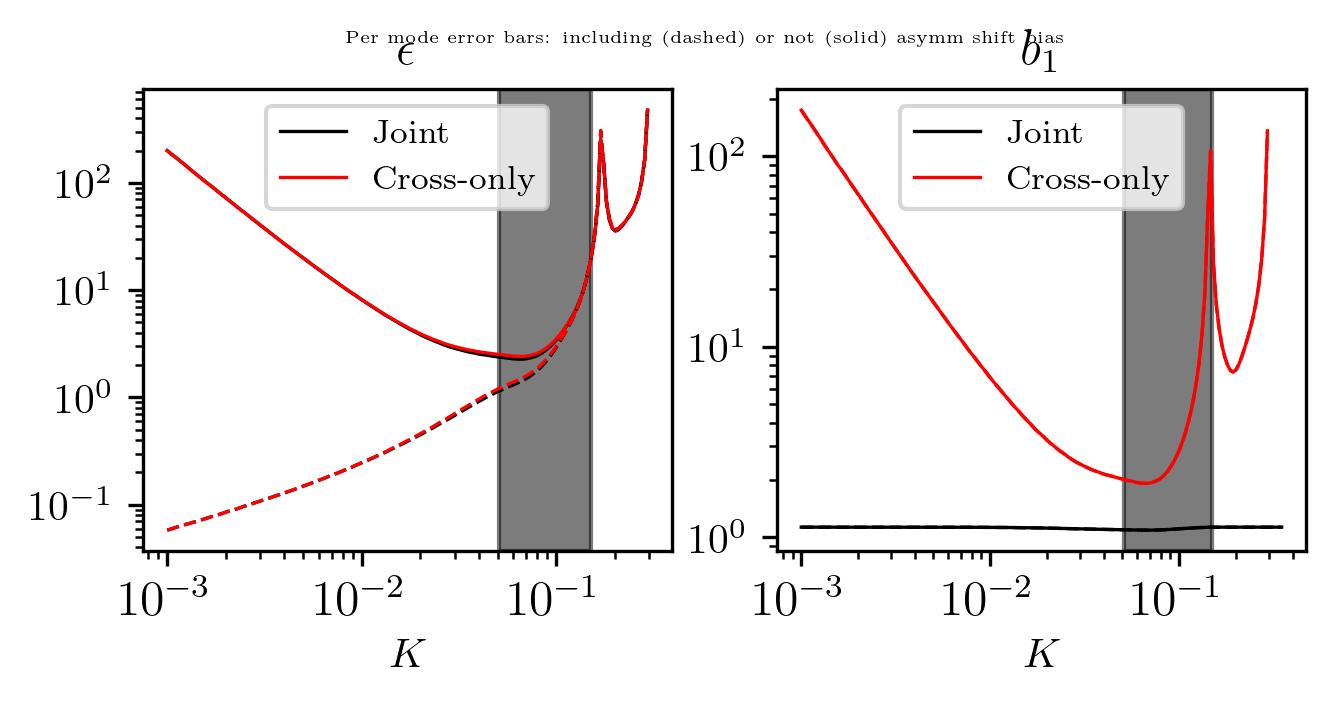

In [13]:
indices = [0] ##, 1]
fig, axs = plt.subplots(1, len(indices), figsize=(5, 2), dpi=plot.DPI, facecolor='white')
labels = ["$\epsilon$", "$b_1$", "$b_2$"]

fig.suptitle("Per mode error bars: including (dashed) or not (solid) asymm shift bias", fontsize = 4)

for index_case, asymm_shift in enumerate([0, 1]):
    
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=variance_factor,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_single = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_single = jnp.nan_to_num(F_single)
    
    F = fisher.fisher_per_mode(vA, Ks, cov)


    for i, index in enumerate(indices):
        ax = axs[i]
        ax.set_title(labels[i])
        ax.loglog(Ks, F[:, index, index]**-0.5, label = "Joint" if index_case == 0 else None, color = "black", ls = "-" if index_case == 0 else "--")
        ax.loglog(Ks, F_single[:, index, index]**-0.5, color = "red", label = "Cross-only" if index_case == 0 else None, ls = "-" if index_case == 0 else "--")
        ax.set_xlabel("$K$")
        #ax.set_xlim(1e-3, 1e-1)
        #ax.set_ylim(1e-6)
        ax.axvspan(QR.kmin, QR.kmax, alpha=0.3, color = 'black')
        ax.legend()
#fig.tight_layout()

In [14]:
#vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
selected = [0, 1] #, 7, 8]

matrix = F[:, selected][:, :, selected]
F_inv_marg = jnp.linalg.inv(matrix)
F_inv_single_marg = jnp.linalg.inv(F_single[:, selected][:, :, selected])

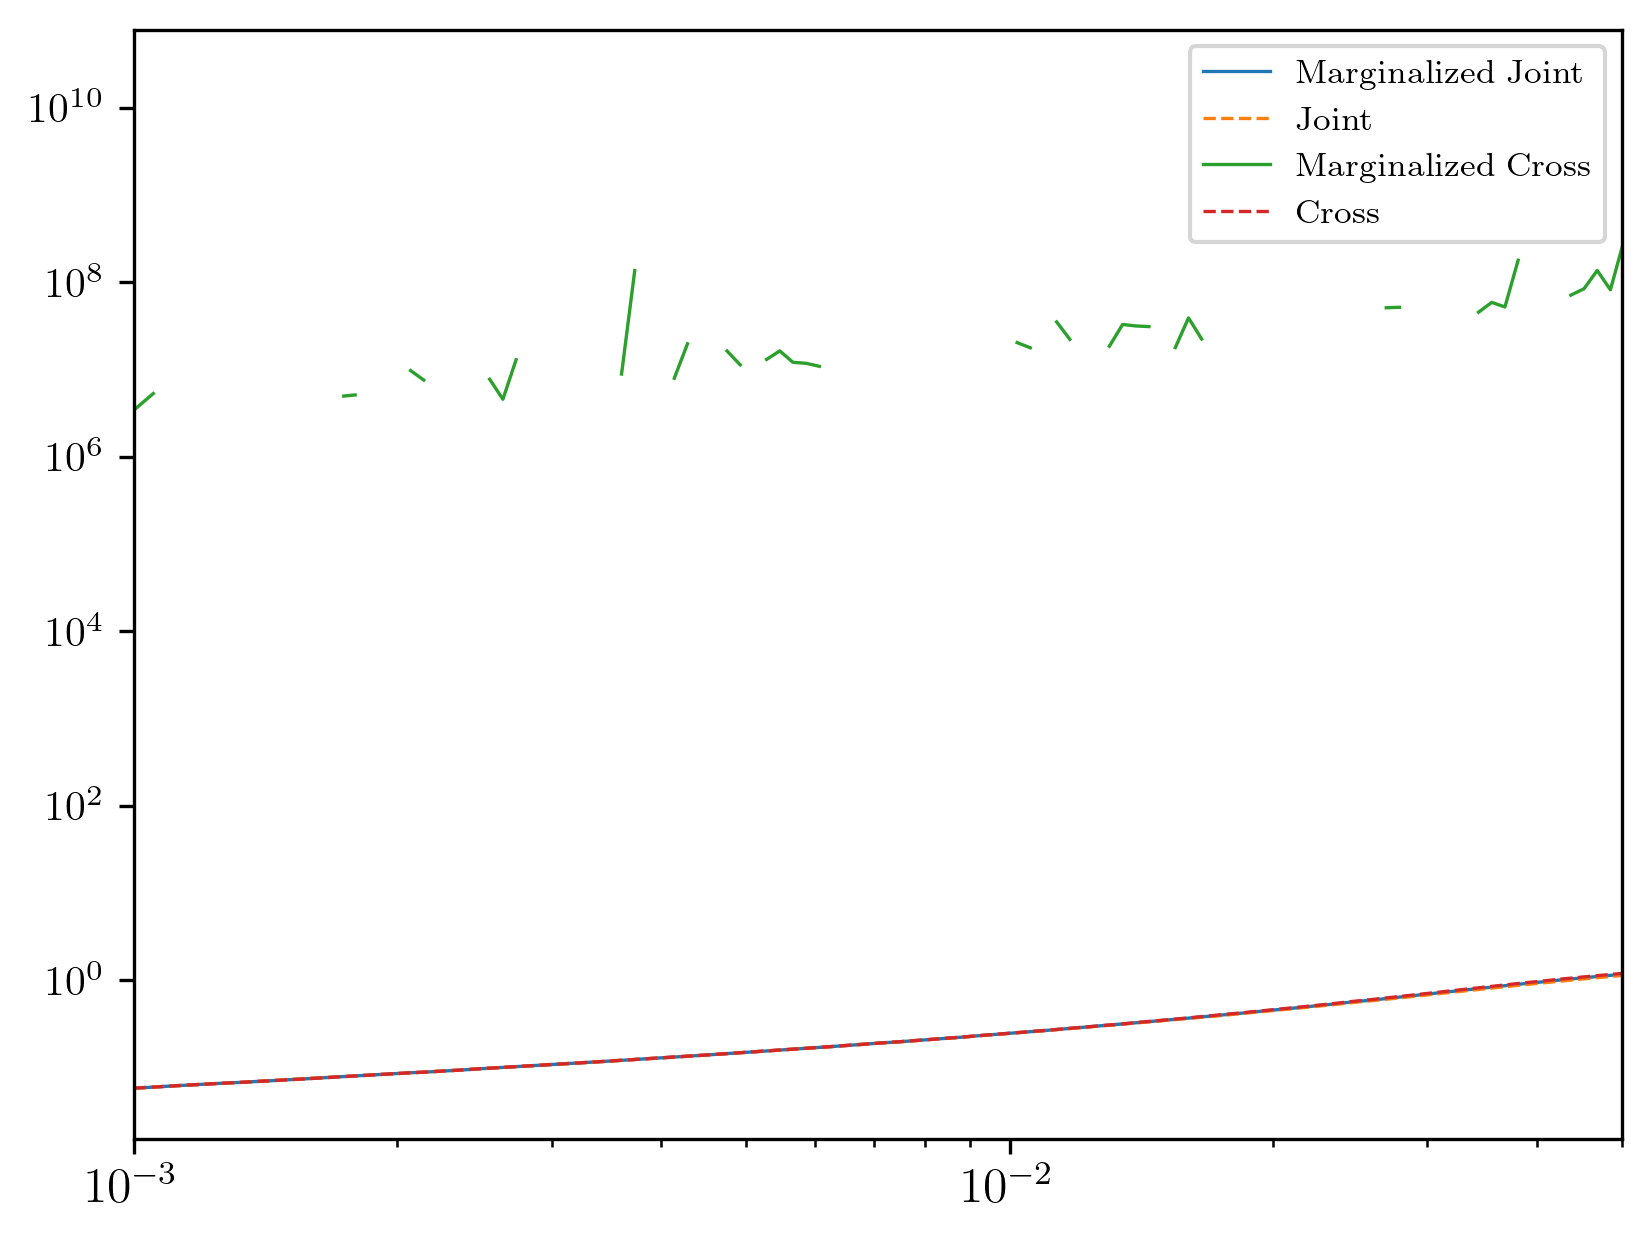

In [15]:
index = 0 #this is the original indexing!!!

min_sel = min(selected)

err_marg = F_inv_marg[:, index-min_sel, index-min_sel]**0.5
err_single_marg = F_inv_single_marg[:, index-min_sel, index-min_sel]**0.5

p = plt.loglog(Ks, err_marg, label = "Marginalized Joint")
plt.loglog(Ks, F[:, index, index]**-0.5, label = "Joint", ls = "--")

p = plt.loglog(Ks, err_single_marg, label = "Marginalized Cross")
plt.loglog(Ks, F_single[:, index, index]**-0.5, label = "Cross", ls = "--")
plt.xlim(1e-3, 5e-2)
plt.legend()

## Paper results

In [16]:
def get_integrated_fisher(K_array, F, Kmin = 0.001, Kmax = 0.05, V = 1, Narr = 20):
    
    err_ms, err_us = [], []
    
    Kmaxarr = min(0.2, Kmax)
    modes = jnp.logspace(np.log10(Kmin), np.log10(Kmaxarr), Narr) if Narr > 1 else [Kmin]

    F_int = []
    for KK in modes:
        F_int.append(fisher.get_F_integrated_fast(K_array, F, KK, Kmax, V = V, N = 999))
        
    return modes, F_int

In [17]:
Kmax = 5e-2
def ger_errors(fisher, selected, Kmin, Kmax, V, Narr = 50):
    modes, F_int = get_integrated_fisher(Ks, fisher[:, selected][:, :, selected], Kmin = Kmin, Kmax = Kmax, V = V, Narr = Narr)
    err_matrix = jnp.array([jnp.diag(F_)**-0.5 for F_ in F_int])
    err_marginalized_matrix = jnp.array([jnp.diag(jnp.linalg.inv(F_))**0.5 for F_ in F_int])
    return modes, err_matrix, err_marginalized_matrix

In [18]:
from qeep import fisher

#vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point

def get_spectra_info(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps):
    
    vA = jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point
        
    vfid = None
    fiducial_auto = False
    fiducial_cross = False
    fiducial_power = False
        
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
            mainkey,
            QR,
            shot_noise=shot_noise,
            variance_factor=variance_factor,
            bispectrum_factor=bispectrum_factor,
            trispectrum_factor=trispectrum_factor,
            asymm_shift=asymm_shift,
            only_asymm_shift=only_asymm_shift,
            growth_eps=growth_eps,
            vfid=vfid,
            fiducial_auto=fiducial_auto,
            fiducial_cross=fiducial_cross,
            fiducial_power=fiducial_power
        ))
        

    return vA, CAA, CAR, CRR
    
def get_full_fisher(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps, r2 = False):
    
    vA, cov, O, Ovar = get_spectra_info(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps)
        
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_cross = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_cross = jnp.nan_to_num(F_cross)
    
    F_joint = fisher.fisher_per_mode(vA, Ks, cov)

    if not r2:
        return F_cross, F_joint
    else:
        gr = CAR(vA)
        rr = CRR(vA)
        gg = CAA(vA)
        r2 = gr**2/(gg*rr)
        return F_cross, F_joint, r2

In [30]:
from copy import deepcopy

configurations = {}

configuration_base = {"mainkey": "n",
                      "QR": QR,
                      "e": 0.,
                      "shot_noise": 1/nbar_A, 
                      "variance_factor": 1., 
                      "bispectrum_factor": 0., 
                      "trispectrum_factor": 0., 
                      "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                      "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                      "growth_eps": 0., #enhanced growth for galaxy clustering
                     }

configuration_no_shot = deepcopy(configuration_base)
configuration_no_shot["shot_noise"] = 0.

configuration_no_noise = deepcopy(configuration_base)
configuration_no_noise["shot_noise"] = 0.
configuration_no_noise["variance_factor"] = 1e-4

configuration_growth_no_noise = deepcopy(configuration_base)
configuration_no_noise["shot_noise"] = 0.
configuration_no_noise["variance_factor"] = 1e-4
configuration_no_noise["growth_eps"] = 1.

configuration_growth = deepcopy(configuration_base)
configuration_growth["growth_eps"] = 1.

configuration_only_asymm = deepcopy(configuration_base)
configuration_only_asymm["only_asymm_shift"] = 1.

configuration_all_shot = deepcopy(configuration_base)
configuration_all_shot["bispectrum_factor"] = 1.
configuration_all_shot["trispectrum_factor"] = 1.

configurations["base"] = configuration_base
#configurations["no_shot_noise"] = configuration_no_shot
configurations["no_noise"] = configuration_no_noise
configurations["growth_eps"] = configuration_growth
configurations["growth_eps_no_noise"] = configuration_growth_no_noise
configurations["only_asymm_shift"] = configuration_only_asymm
#configurations["all_shot_noise"] = configuration_all_shot

In [31]:
#import jax
#gpus = jax.devices('gpu')
#import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Only GPU 1 will be visible to JAX

In [32]:
h = 0.67
V = 5  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)
print(k_min_analysis)

0.0036744290581343145


In [33]:
selected = [0, 1, 2, 3]#, 4, 5, 6]
Narr = 70

out_results = {}
for k, conf in configurations.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)
    out_results[k] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results[k]["F_joint"] = F_joint
    out_results[k]["F_cross"] = F_cross
    print("Done", k)

selected_alt = [0, 1]#, 4, 5, 6]
out_results_alt = {}
for k, conf in configurations.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected_alt, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected_alt, k_min_analysis, Kmax, V, Narr = Narr)
    out_results_alt[k] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results_alt[k]["F_joint"] = F_joint
    out_results_alt[k]["F_cross"] = F_cross
    print("Done", k)

Done base
Done no_noise
Done growth_eps
Done growth_eps_no_noise
Done only_asymm_shift
Done base
Done no_noise
Done growth_eps
Done growth_eps_no_noise
Done only_asymm_shift


In [34]:
F_cross, F_joint, r2 = get_full_fisher(**configurations["only_asymm_shift"], r2 = True)
modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)

In [35]:
vA, CAA, CAR, CRR = get_spectra_info(**configurations["only_asymm_shift"])

In [36]:
#plt.plot(Ks, r2)
#plt.plot(Ks, CAR(vA)**2/(CAA(vA)*CRR(vA)), ls = "--")

In [37]:
P_AA = CAA(vA)
P_AR = CAR(vA)
P_RR = CRR(vA)

CAA_ = lambda e: CAA(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
CAR_ = lambda e: CAR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
CRR_ = lambda e: CRR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))

efid = jnp.array([0.])[0]
der_AA = jax.jacfwd(CAA_)(efid)
der_AR = jax.jacfwd(CAR_)(efid)
der_RR = jax.jacfwd(CRR_)(efid)

def compute_fisher_aa(P_AA, P_AR, P_RR, der_AA, der_AR, der_RR, rfactor = 1.):
    """
    Compute Fisher matrix element F_aa using equation (52)
    
    Parameters:
    -----------
    P_AA, P_AR, P_RR : power spectrum values
    der_AA, der_AR, der_RR : derivatives of power spectra w.r.t. parameter a
    """
    
    # Compute correlation coefficient r_cc^2
    r2 = P_AR**2 / (P_AA * P_RR) * rfactor
    r_cc = jnp.sqrt(r2)
    
    # Compute normalized derivatives
    norm_der_AA = der_AA / P_AA
    norm_der_AR = der_AR / P_AR
    norm_der_RR = der_RR / P_RR
    
    # First term: (∂_a P^gg/P^gg - 2r_cc^2 ∂_a P^gr/P^gr)^2
    term1 = (norm_der_AA - 2*r2*norm_der_AR)**2
    
    # Second term: 2r_cc^2(1-r_cc^2)(∂_a P^gr/P^gr)^2
    term2 = 2*r2*(1 - r2)*(norm_der_AR)**2
    
    # Third term: 2r_cc^2 (∂_a P^rr/P^rr)(∂_a P^gg/P^gg - 2∂_a P^gr/P^gr)
    term3 = 2*r2*norm_der_RR*(norm_der_AA - 2*norm_der_AR)
    
    # Fourth term: (∂_a P^rr/P^rr)^2
    term4 = norm_der_RR**2
    
    # Combine all terms
    numerator = term1 + term2 + term3 + term4
    denominator = 2*(1 - r2)**2
    
    F_aa = numerator / denominator
    
    return F_aa

In [38]:
r2 = P_AR**2/(P_AA*P_RR)

F_joint_analytical = 0.5*1/(1-r2)**2*((der_AA*0./P_AA)**2+(der_RR*0./P_RR)**2+2*r2*(1-r2)*(der_AR/P_AR)**2)

F_joint_aa = compute_fisher_aa(P_AA, P_AR, P_RR, der_AA, der_AR, der_RR, rfactor = 1.)

F_cross_analytical = ((der_AR)**2/(P_AA*P_RR+P_AR**2))

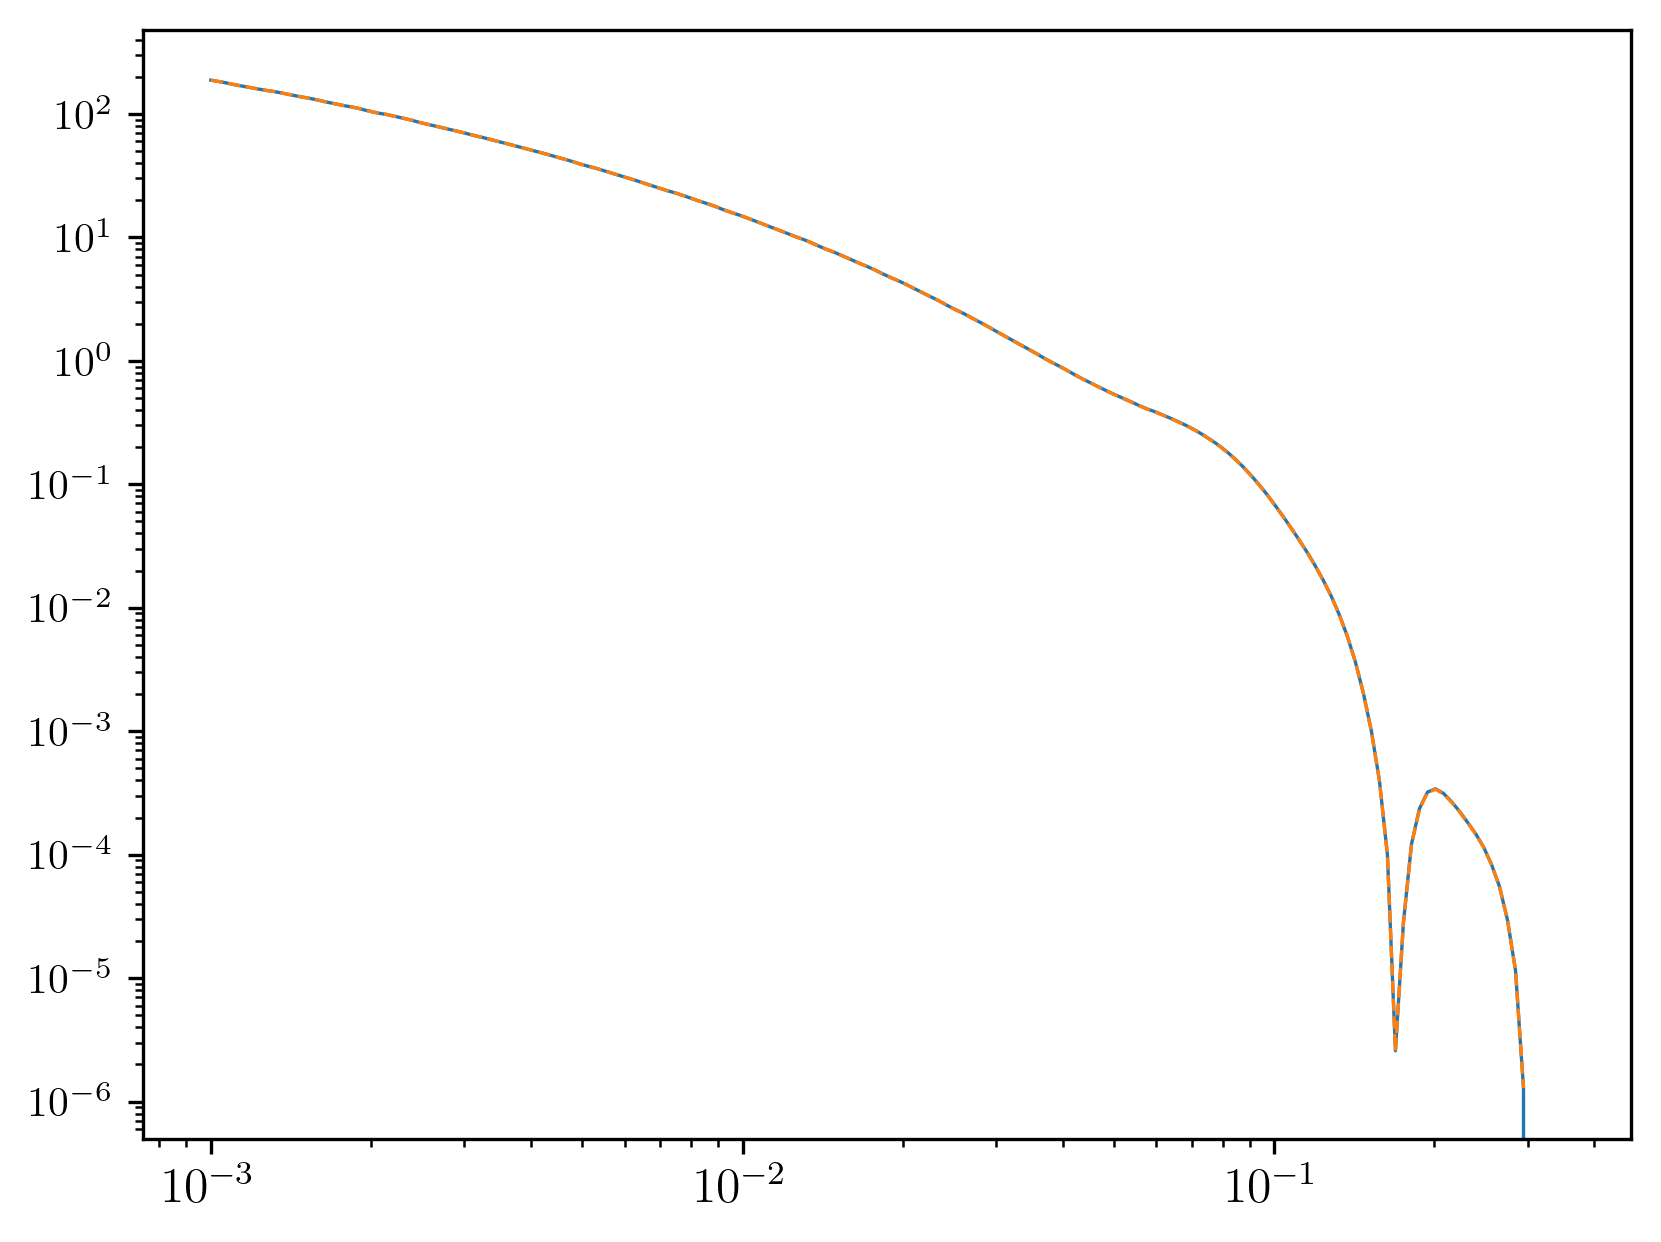

In [39]:
index = 0

plt.loglog(Ks, F_joint[:, index, index])
plt.loglog(Ks, F_joint_analytical, ls = "--")

#plt.loglog(Ks, F_cross[:, index, index])
#plt.loglog(Ks, F_cross_analytical, ls = ":")

/tmp/ipykernel_42188/3996677706.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


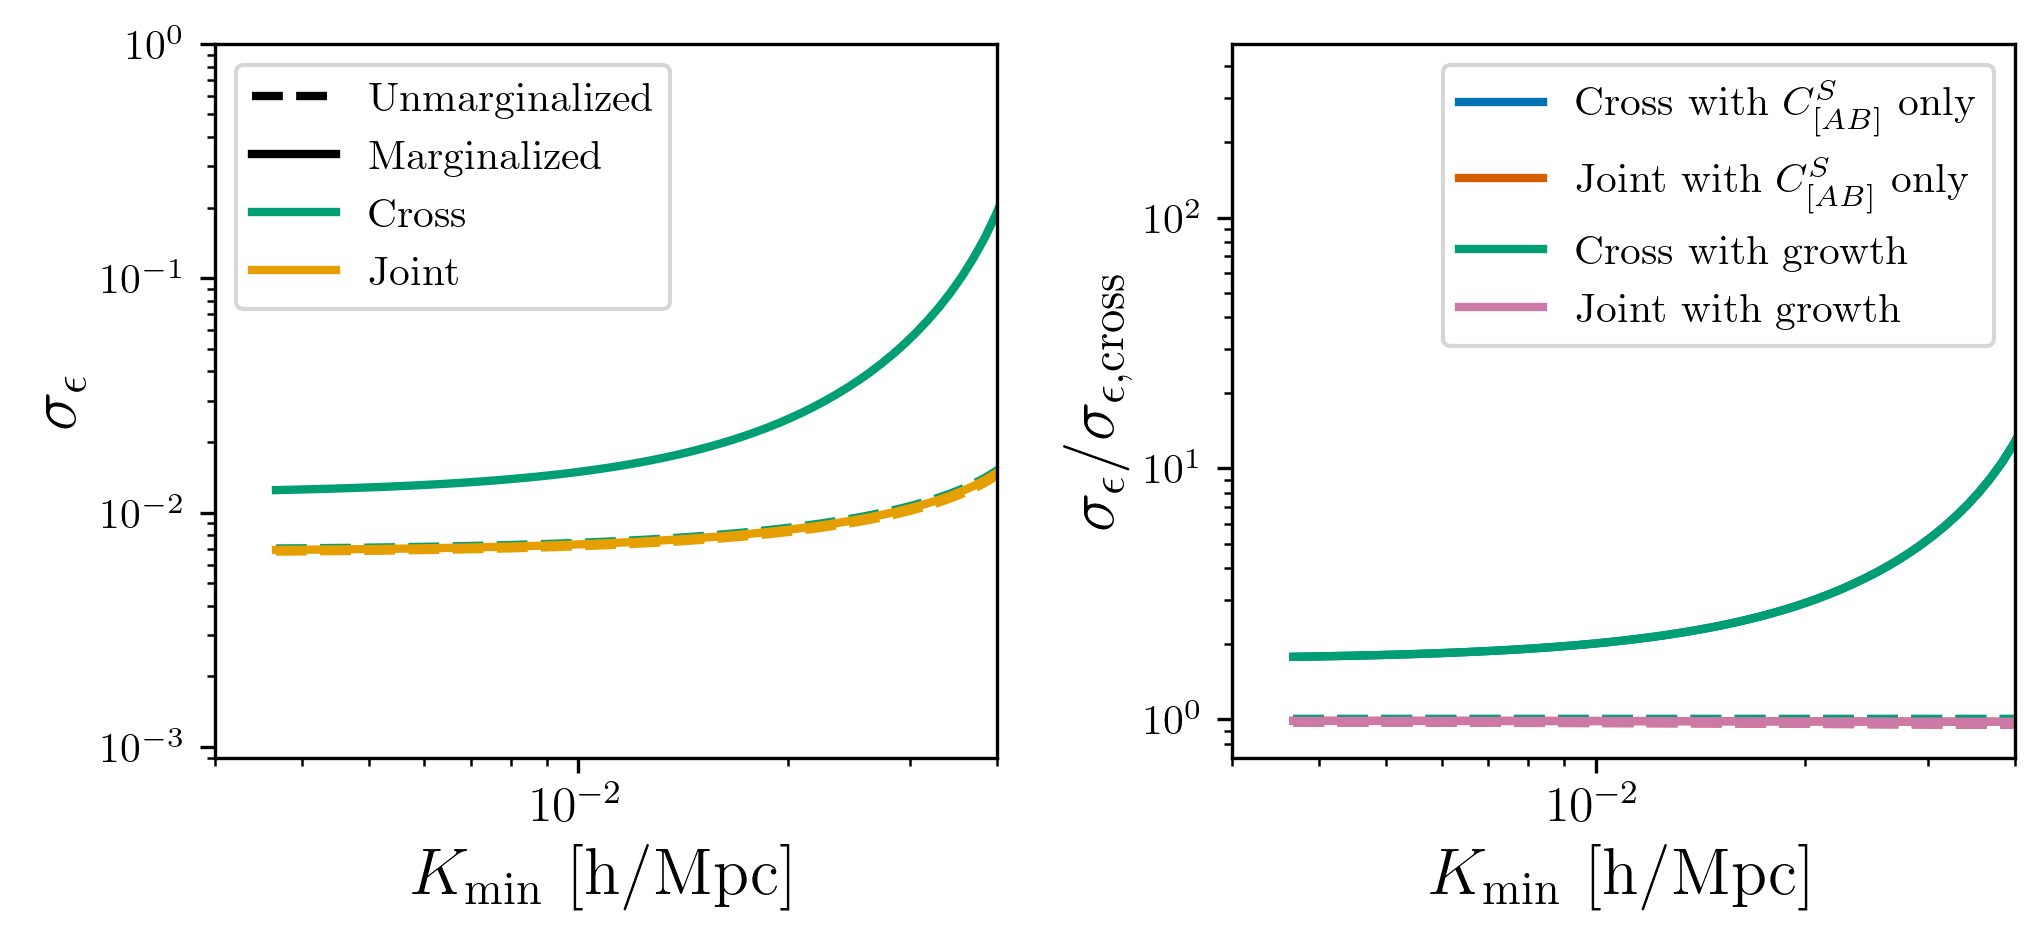

In [29]:
index = 0

from matplotlib.lines import Line2D

fig = plt.figure(figsize=(1.5*plot.FIG_WIDTH, plot.FIG_HEIGHT), dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 2, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
#ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
#               top=True, right=False)
#ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
#               top=True, right=False)
out_selected = out_results
out_selected = out_results_alt


keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])
keybase = "base"
results = out_selected[keybase]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]

color = lambda i: plot.COLORBLIND_PALETTE[i % len(plot.COLORBLIND_PALETTE)]

s1, s2 = 2, 5

base = 1#err_matrix_cross[:, index]
ax.loglog(modes, err_matrix_cross[:, index]/base, color = color(s1), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix_cross[:, index]/base, color = color(s1), lw=2)

ax.loglog(modes, err_matrix[:, index]/base, color = color(s2), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix[:, index]/base, color = color(s2), lw=2)

#ax.set_ylim(ymin = 2e-3, ymax = 1)
ax.set_ylim(ymin = 9e-4, ymax = 1)
ax.set_xlim(3e-3, 4e-2)
ax.set_xlabel(r'$K_{\mathrm{min}} \ [h/\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\sigma_{\epsilon}$', fontsize=16)

legend_elements = [
    Line2D([0], [0], color = 'black', lw=2, linestyle='--', label='Unmarginalized'),
    Line2D([0], [0], color = 'black', lw=2, label='Marginalized'),
    Line2D([0], [0], color = color(s1), lw=2, label='Cross'),
    Line2D([0], [0], color = color(s2), lw=2, label='Joint')
]

ax.legend(handles=legend_elements, loc='best', fontsize=10)

ax = fig.add_subplot(gs[0, 1])

base = err_matrix_cross[:, index]
legend_elements = []

keybase = "only_asymm_shift"
results = out_selected[keybase]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
color_index = 0
ax.loglog(modes, err_matrix_cross[:, index]/base, color = color(color_index), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix_cross[:, index]/base, color = color(color_index), lw=2)
ax.loglog(modes, err_matrix[:, index]/base, color = color(color_index+1), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix[:, index]/base, color = color(color_index+1), lw=2)

legend_elements = [
    Line2D([0], [0], color = color(color_index), lw=2, label = 'Cross with $C^{S}_{[AB]}$ only'),
    Line2D([0], [0], color = color(color_index+1), lw=2, label = 'Joint with $C^{S}_{[AB]}$ only')
]

keybase = "growth_eps"
results = out_selected[keybase]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]

color_index = 2
ax.loglog(modes, err_matrix_cross[:, index]/base, color = color(color_index), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix_cross[:, index]/base, color = color(color_index), lw=2)

ax.loglog(modes, err_matrix[:, index]/base, color = color(color_index+1), ls = "--", lw=2)
ax.loglog(modes, err_marginalized_matrix[:, index]/base, color = color(color_index+1), lw=2)

legend_elements += [
    Line2D([0], [0], color = color(color_index), lw=2, label = 'Cross with growth'),
    Line2D([0], [0], color = color(color_index+1), lw=2, label = 'Joint with growth')]


#keybase = "no_noise"
#results = out_results[keybase]
#modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
#color_index = 4
#ax.loglog(modes, err_matrix_cross[:, index]/base, color = color(color_index), ls = "--")
#ax.loglog(modes, err_marginalized_matrix_cross[:, index]/base, color = color(color_index))
#ax.loglog(modes, err_matrix[:, index]/base, color = color(color_index+1), ls = "--")
#ax.loglog(modes, err_marginalized_matrix[:, index]/base, color = color(color_index+1))
#legend_elements += [
#    Line2D([0], [0], color = color(color_index), lw=2, label = 'Cross no noise'),
#    Line2D([0], [0], color = color(color_index+1), lw=2, label = 'Joint no noise')]

#ax.set_ylim(ymin = 9e-4, ymax = 1)
ax.set_xlim(3e-3, 4e-2)

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon,\mathrm{cross}}$', fontsize=16)
ax.set_xlabel(r'$K_{\mathrm{min}} \ [h/\mathrm{Mpc}]$', fontsize=14)



ax.legend(handles=legend_elements, loc='best', fontsize=10)


plt.subplots_adjust(wspace=0.3)
fig.savefig(f"/users/odarwish/long-modes/figures/fisher_base.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

## Understanding constraints

## Cosmic variance cancellation

In [24]:
from copy import deepcopy

configurations_noise = {}

QR = qres.QEResults(config)

configuration_base = {"mainkey": "n",
                      "QR": QR,
                      "e": 0.,
                      "shot_noise": 1/config["number_density"]["nbar_A"], 
                      "variance_factor": 1., 
                      "bispectrum_factor": 0., 
                      "trispectrum_factor": 0., 
                      "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                      "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                      "growth_eps": 0., #enhanced growth for galaxy clustering
                     }

N = 30
cases = [f"noise_{i}" for i in range(N)]
factors = np.array([np.exp(i)*1e-8 for i in range(N)])

factors = np.append(factors, 1)
cases.append(f"base")

for i, case in enumerate(cases):
    config_temp = deepcopy(configuration_base)
    config_temp["shot_noise"] *= factors[i]
    config_temp["variance_factor"] *= factors[i]
    configurations_noise[i] = config_temp

In [25]:
h = 0.67
V = 5  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)

##vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point
selected = [0, 1, 2, 3]#, 4, 5, 6]
selected_extended = [0, 1, 2, 3, 4, 5] #, 8, 9]
Narr = 1

out_results = {}
for k, conf in configurations_noise.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)

    modes, err_matrix_extended, err_marginalized_matrix_extended = ger_errors(F_joint, selected_extended, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross_extended, err_marginalized_matrix_cross_extended = ger_errors(F_cross, selected_extended, k_min_analysis, Kmax, V, Narr = Narr)

    temp_res = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}

    temp_res["err_matrix_extended"] = err_matrix_extended
    temp_res["err_marginalized_matrix_extended"] = err_marginalized_matrix_extended
    temp_res["err_matrix_cross_extended"] = err_matrix_cross_extended
    temp_res["err_marginalized_matrix_cross_extended"] = err_marginalized_matrix_cross_extended
    
    out_results[factors[k]] = temp_res
    out_results[factors[k]]["F_joint"] = F_joint
    out_results[factors[k]]["F_cross"] = F_cross
    print("Done", k)

Done 0
Done 1
Done 2
Done 3
Done 4
Done 5
Done 6
Done 7
Done 8
Done 9
Done 10
Done 11
Done 12
Done 13
Done 14
Done 15
Done 16
Done 17
Done 18
Done 19
Done 20
Done 21
Done 22
Done 23
Done 24
Done 25
Done 26
Done 27
Done 28
Done 29
Done 30


In [26]:
keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0
results = out_results[1]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
base = err_matrix_cross[:, index]

k = 'err_matrix_cross'
errors_noise_cross = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_cross'
errors_marginalized_noise_cross = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_cross_extended'
errors_marginalized_noise_cross_extended = np.array([out_results[f][k][:, index]/base for f in factors])

k = 'err_matrix'
errors_noise_joint = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix'
errors_marginalized_noise_joint = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_extended'
errors_marginalized_noise_joint_extended = np.array([out_results[f][k][:, index]/base for f in factors])

#results = out_results[keybase]
#modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]

/tmp/ipykernel_243744/1870607299.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


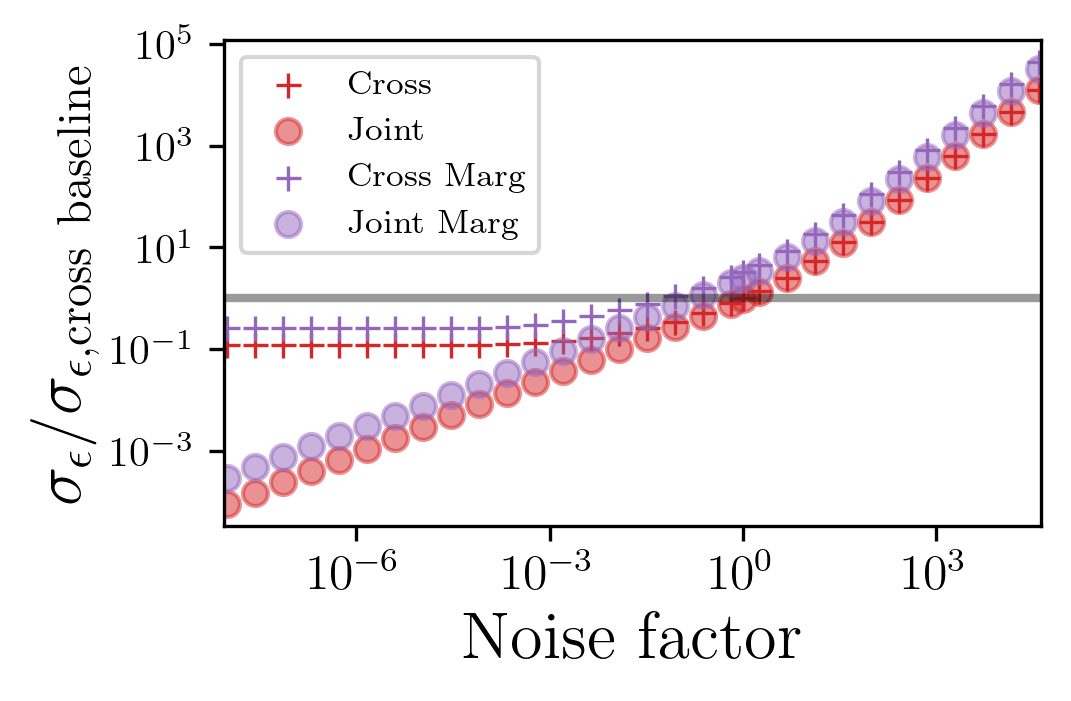

In [27]:
index = 0

from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])


color = lambda i: plot.COLORBLIND_PALETTE_2[i]

ax.hlines(1, factors.min()*(1-0.1), factors.max()*(1+0.1), color = "black", lw = 2, alpha = 0.4)

i = 3
ax.scatter(factors, errors_noise_cross, label = "Cross", color = color(i), marker = "+")
ax.scatter(factors, errors_noise_joint, label = "Joint", color = color(i), alpha = 0.5)

i = 4
ax.scatter(factors, errors_marginalized_noise_cross, label = "Cross Marg", color = color(i), marker = "+")
#ax.scatter(factors, errors_marginalized_noise_cross_extended, label = "Cross Marg Extended", color = color(i), marker = "+")

ax.scatter(factors, errors_marginalized_noise_joint, label = "Joint Marg", color = color(i), alpha = 0.5)



ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon,\mathrm{cross\ baseline}}$', fontsize=16)
ax.set_xlabel(r'Noise factor', fontsize=16)

ax.set_xlim(factors.min()*(1-0.1), factors.max()*(1+0.1))
ax.legend(fontsize = 8)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"/users/odarwish/long-modes/figures/fisher_varying_noise.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

# Directly varying number density

In [28]:
import jax.numpy as jnp

import numpy as np

import pathlib


class QEResults:
    def __init__(self, config, sims = False, relative_path = "."):

        name_config = config['name']
        output_config = config['output']
        relative_path = pathlib.Path(relative_path)
        output_dir = relative_path / output_config['directory'] / name_config

        if sims:
            nome = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_normalization_AB.npy"
            nomev = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_variance_AB.npy"
            nometri = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_trispectrum_AB.npy"
            nomebis_mixed = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_cross_shot_AB.npy"
            nomebis = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_bispectrum_AB.npy"
        else:
            nome = f"analysis_theory_normalization_AB.npy"
            nomev = f"analysis_theory_variance_AB.npy"
            nomebis = f"analysis_theory_shot_bispectrum_AB.npy"
            nomebis_mixed = f"analysis_theory_cross_shot_AB.npy"
            nometri = f"analysis_theory_shot_trispectrum_AB.npy"

        self.out_normalization_AB = np.load(output_dir / nome, allow_pickle = True).item() #inverse of normalization N

        self.analysis_cross_shot_AB = np.load(output_dir / nomebis_mixed, allow_pickle = True).item() #cross shot-noise
        self.out_variance_AB = np.load(output_dir / nomev, allow_pickle = True).item() #variance
        self.out_shot_trispectrum = np.load(output_dir / nometri, allow_pickle = True).item() #trispectrum shot noise, assuming all the same
        self.out_shot_bispectrum = np.load(output_dir / nomebis, allow_pickle = True).item() #bispectrum shot noise, assuming all the same


        ps_main_directory = relative_path / config['power_spectrum']['main_directory']
        self.gen_nl_power = np.loadtxt(ps_main_directory/name_config/config['power_spectrum']['nonlinear'])
        self.gen_power = np.loadtxt(ps_main_directory/name_config/config['power_spectrum']['linear'])

        self.pnlinf = lambda kmag: jnp.interp(kmag, self.gen_nl_power[:,0], self.gen_nl_power[:,1])
        self.plinf = lambda kmag: jnp.interp(kmag, self.gen_power[:,0], self.gen_power[:,1])

        kr_config = config['k_range']
        kmin = kr_config['kmin']
        kmax = kr_config['kmax']
        k_samples = kr_config['k_samples']
        k_min_analysis = kr_config['k_min_analysis']
        k_max_analysis = kr_config['k_max_analysis']

        self.kmin = kmin
        self.kmax = kmax
        self.k_min_analysis = k_min_analysis
        self.k_max_analysis = k_max_analysis

        kmin_max = 2*k_min_analysis
        Ks_ = jnp.linspace(k_min_analysis, kmin_max, 20)
        Ks = jnp.logspace(jnp.log10(kmin_max), jnp.log10(k_max_analysis), k_samples)
        Ks = jnp.concatenate([Ks_, Ks])
        self.Ks = jnp.unique(Ks)

    def get_out_normalization_AB(self):
        result = {}
        for key, value in self.out_normalization_AB.items():
            value = np.array(value)
            value[np.abs(value)<1e-10] = 0
            result[key] = jnp.array(value)
        return result

    def get_get_norm(self):
        def get_norm(key):
            N = np.array(self.out_normalization_AB[(key, key)]**-1.)
            N[np.abs(N)>1e10] = 0
            N = jnp.array(N)
            return N
        return get_norm
    
    def get_get_variance(self):
        def get_variance(key):
            N = self.get_get_norm()(key)
            V = self.out_variance_AB[(key, key)]*N**2
            return V
        return get_variance
    
    def get_get_trispectrum(self):
        def get_trispectrum(key):
            N = self.get_get_norm()(key)
            T = self.out_shot_trispectrum[(key, key)]*N**2
            return T
        return get_trispectrum

    def get_get_bispectrum_mixed(self):
        def get_bispectrum_mixed(key):
            N = self.get_get_norm()(key)
            B = self.analysis_cross_shot_AB[(key, key)]*N
            return B
        return get_bispectrum_mixed

    def get_get_bispectrum(self):
        def get_bispectrum(key):
            N = self.get_get_norm()(key)
            B = self.out_shot_bispectrum[(key, key)]*N
            return B
        return get_bispectrum


    def get_get_tot_noises(self):
        def get_tot_noises(key):
            variance = self.get_get_variance()(key)
            bispectrum = self.get_get_bispectrum()(key)
            trispectrum = self.get_get_trispectrum()(key)
            bispectrum_mixed = self.get_get_bispectrum_mixed()(key)
            return variance, bispectrum, trispectrum, bispectrum_mixed

    @staticmethod
    def E_bottaro():
        z_eq = 3400
        a_eq = 1/(1+z_eq)
        a = 1.
        fchi = 1.
        factor = jnp.log(a/a_eq)-181/90
        factor *= fchi
        factor *= 6/5
        return factor

    def get_G(self):
        def G(epsilon, one = 1):
            E = self.E_bottaro()
            return 1+epsilon*E*one
        return G
    


def get_normalization_array(key, keys, Ks, out_normalization_AB):
    jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
    for i, k in enumerate(keys):
        jax_out_normalization_AB[i, :] = out_normalization_AB[(key, k)]
    jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)
    return jax_out_normalization_AB

In [29]:
from copy import deepcopy


selected = [0, 1, 2, 3]#, 4, 5, 6]
Narr = 1

out_results = {}
nbars = []

conf_indices = list(range(1, 32))

conf_vary_kmax_indices = list(range(25, 31))
nbars_kmax = []

conf_ok = []
for i in conf_indices:
    
    configuration_i = f'../../configs/abacus/desi_nbars/config_desi_base_{i}.yaml'

    with open(configuration_i, 'r') as f:
        config_i = yaml.safe_load(f)

    name = config_i["name"]
    path = f"../../results/{name}/"
    #path = f"/users/odarwish/results/desi_base_asymm/"
    
    try:
        QR = QEResults(config_i, relative_path = "../")
    except:
        print(i, "not found")
        continue

    if i not in conf_vary_kmax_indices:
        conf_ok.append(i)
        nbars.append(config_i["number_density"]["nbar_A"])
    else:
        nbars_kmax.append(config_i["number_density"]["nbar_A"])
    
    configuration_base_i = {"mainkey": "n",
                          "QR": QR,
                          "e": 0.,
                          "shot_noise": 1/config_i["number_density"]["nbar_A"], 
                          "variance_factor": 1., 
                          "bispectrum_factor": 0., 
                          "trispectrum_factor": 0., 
                          "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                          "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                          "growth_eps": 0., #enhanced growth for galaxy clustering
                         }

    F_cross, F_joint = get_full_fisher(**configuration_base_i)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)
    out_results[i] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results[i]["F_joint"] = F_joint
    out_results[i]["F_cross"] = F_cross
    

7 not found
8 not found
9 not found


In [30]:
nbars = np.array(nbars)

keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0

argmin = np.argmin(abs(nbars-0.0018))
base_nbar_index = conf_ok[argmin]
results = out_results[base_nbar_index]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
base = err_matrix_cross[:, index]

k = 'err_matrix_cross'
errors_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix_cross'
errors_marginalized_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

k = 'err_matrix'
errors_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix'
errors_marginalized_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

k = 'err_marginalized_matrix'
errors_marginalized_noise_joint_nbar_kmax = np.array([out_results[f][k][:, index]/base for f in conf_vary_kmax_indices])

/tmp/ipykernel_243744/314226828.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


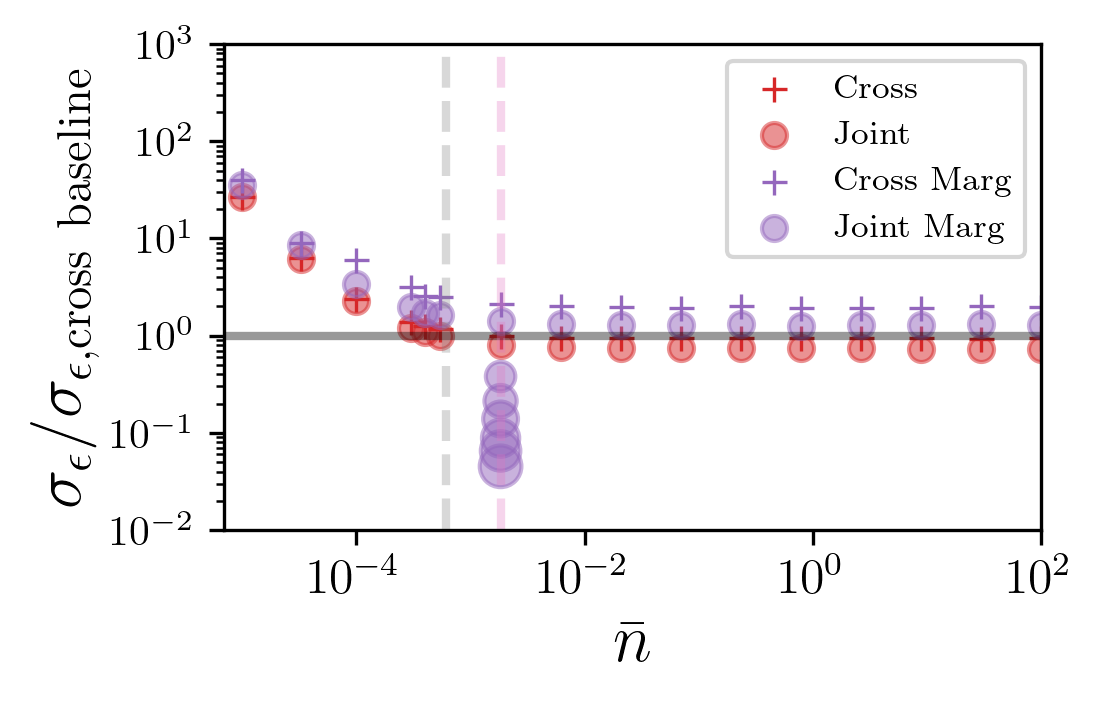

In [31]:
import matplotlib.cm as cm

index = 0

nbar_1 = nbars[argmin] #
nbar_2 = 1e-3 #
nbar_3 = 0.33*nbar_1

from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

color = lambda i: plot.COLORBLIND_PALETTE_2[i]


ax.hlines(1, nbars.min()*(1-0.1), nbars.max()*(1+0.1), color = "black", lw = 2, alpha = 0.4)

ax.vlines(nbar_1, 1e-7, 2e3, color = color(6), ls = "--", lw = 2, alpha = 0.3)
#ax.vlines(nbar_2, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)
ax.vlines(nbar_3, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)


i = 3
ax.scatter(nbars, errors_noise_cross_nbar, label = "Cross", color = color(i), marker = "+")
ax.scatter(nbars, errors_noise_joint_nbar, label = "Joint", color = color(i), alpha = 0.5)

i = 4
ax.scatter(nbars, errors_marginalized_noise_cross_nbar, label = "Cross Marg", color = color(i), marker = "+")
ax.scatter(nbars, errors_marginalized_noise_joint_nbar, label = "Joint Marg", color = color(i), alpha = 0.5)


#ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, label = "Joint Marg Increasing $k_{\mathrm{max,rec}}$", color = color(5), alpha = 0.5)

n_kmax_points = len(nbars_kmax)
colors_kmax = cm.viridis(np.linspace(0.2, 0.8, n_kmax_points))  # or use cm.plasma, cm.coolwarm
#for i, (x, y) in enumerate(zip(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax)):
#    ax.scatter(x, y, color=colors_kmax[i], alpha=0.7)

marker_sizes = np.linspace(50, 100, len(nbars_kmax))  # sizes increase with kmax
ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, 
           s=marker_sizes, color=color(i), alpha=0.5)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon,\mathrm{cross\ baseline}}$', fontsize=14)
ax.set_xlabel(r'$\bar{n}\ h^3\mathrm{[/Mpc^3]}$', fontsize=14)

ax.legend(fontsize = 8)

ax.set_xlim(nbars.min()*(1-0.1), nbars.max()*(1+0.1))
ax.set_xlim(7e-6, 100)
ax.set_ylim(1e-2, 1e3)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"/users/odarwish/long-modes/figures/fisher_varying_nbar.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()